In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from PIL import Image
from scipy.sparse import csr_matrix
import numpy as np
import tensorflow as tf
import pickle as pkl
from skimage import measure
import os
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model


# Malignant or Benign?

### Functions for reading, cropping and resizing images:

In [2]:
from PIL import Image
import numpy as np

def load_crop_resize_image(image_path, s, mode="RGB"):
    """
    Load an image with PIL, center-crop it to a square using
    min(width, height), resize to s x s, and select channels.

    Parameters
    ----------
    image_path : str
        Path to the image.
    
    s : int
        Output image size (s x s).
    
    mode : str
        One of:
        - "R"   : red channel
        - "G"   : green channel
        - "B"   : blue channel
        - "RGB" : full RGB image
        - "L"   : grayscale

    Returns
    -------
    np.ndarray
        Processed image as numpy array.
    """

    # Open image
    img = Image.open(image_path).convert("RGB")

    width, height = img.size

    # Square crop size
    crop_size = min(width, height)

    # Center crop coordinates
    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    # Crop
    img = img.crop((left, top, right, bottom))

    # Resize
    img = img.resize((s, s), Image.Resampling.LANCZOS)

    # Channel selection
    mode = mode.upper()

    if mode == "RGB":
        return np.array(img)

    elif mode in ["R", "G", "B"]:
        channel_index = {"R": 0, "G": 1, "B": 2}[mode]
        return np.array(img)[:, :, channel_index]

    elif mode == "L":
        return np.array(img.convert("L"))

    else:
        raise ValueError("mode must be one of: 'R', 'G', 'B', 'RGB', 'L'")

### Function for image contour detection:

In [3]:
import numpy as np
from skimage import measure


def contour_mask(img_np, threshold=None):
    """
    Returns a binary contour mask.

    Parameters
    ----------
    img_np : np.ndarray
        Can be:
        - RGB image: (H, W, 3)
        - Single channel image: (H, W)

    threshold : float or None

    Returns
    -------
    np.ndarray of bool
    """

    # RGB image
    if img_np.ndim == 3:
        gray = (
            0.299 * img_np[:, :, 0] +
            0.587 * img_np[:, :, 1] +
            0.114 * img_np[:, :, 2]
        )

    # Already grayscale / single-channel
    elif img_np.ndim == 2:
        gray = img_np.astype(np.float32)

    else:
        raise ValueError("Unsupported image shape")

    # Threshold
    if threshold is None:
        threshold = gray.mean()

    binary = gray < threshold

    # Find contours
    contours = measure.find_contours(binary, level=0.5)

    # Output mask
    mask = np.zeros(binary.shape, dtype=bool)

    # Draw contours
    for contour in contours:
        coords = np.round(contour).astype(int)

        for y, x in coords:
            if 0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]:
                mask[y, x] = True

    return mask

# Reading data for training our models:

### Reading folds information:

In [21]:
#Replace by the path of your Folds.csv file
path="home/danillo-souza/Downloads/Cancer_Classification_Data_Kaggle/BreakHis_large/Folds.csv"

In [22]:
import pandas as pd

folds = pd.read_csv(
    '/home/danillo-souza/Downloads/Cancer_Classification_Data_Kaggle/BreakHis_large/Folds.csv'
)


### Defining multiclass information: 

In [23]:
folds["multiclass"]=[i.split("/")[5] for i in  folds.filename]

### Defining binary classification information:

In [24]:
folds["target"]=[0 if "benign" in i else 1 for i in folds.filename]

In [25]:
class_dict=dict(enumerate(folds.multiclass.unique()))
class_dict={class_dict[i]:i for i in class_dict}
folds["multiclass_target"]=[class_dict[i] for i in folds.multiclass]

### Restricting data to 40X zoom scans:

In [26]:
folds=folds[folds.mag==40]

In [27]:
class_dict=dict(enumerate(folds.multiclass.unique()))

### Reading train and test files:

In [65]:
path="/home/danillo-souza/Downloads/Cancer_Classification_Data_Kaggle/BreakHis_large/"

In [80]:
train_files=list(set([path+"BreaKHis_v1/"+i for i in folds[folds.grp=="train"].filename.tolist()]))

In [81]:
y_train=np.array([1 if "malignant" in i else 0 for i in train_files])

In [82]:
test_files=list(set([path+"/BreaKHis_v1/"+i for i in folds[folds.grp=="test"].filename.tolist()]))

In [83]:
y_test=np.array([1 if "malignant" in i else 0 for i in test_files])

### Total Malignant:

In [48]:
list(y_train).count(1)

1370

### Total Benign:

In [49]:
list(y_train).count(0)

625

### Hmm, it looks like we have a class inbalance here... Let´s move on and see what happens with the models.

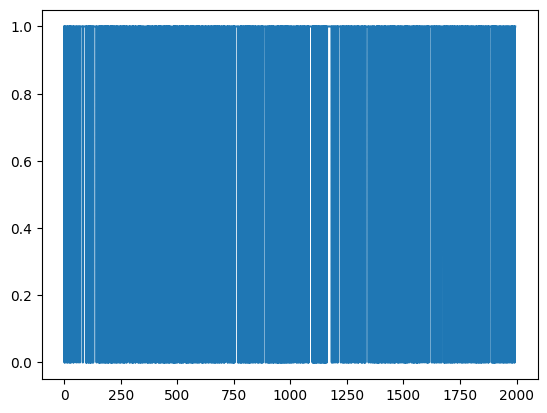

In [50]:
plt.plot(y_train)

### It looks like we will have a bias in our labels. Let's randomize the data with a fixed random seed:

In [89]:
import numpy as np
np.random.seed(40)
# Train
train_idx = np.random.permutation(len(train_files))

train_files = np.array(train_files)[train_idx]
y_train = np.array(y_train)[train_idx]
#y_multi_train = np.array(y_multi_train)[train_idx]

# Test
test_idx = np.random.permutation(len(test_files))

test_files = np.array(test_files)[test_idx]
y_test = np.array(y_test)[test_idx]
#y_multi_test = np.array(y_multi_test)[test_idx]

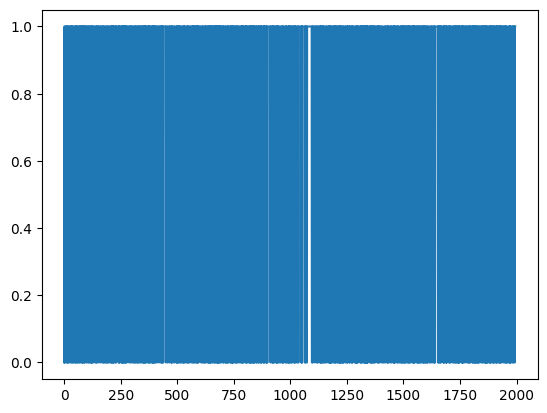

In [91]:
plt.plot(y_train)

### Reading the train data and validation/train data (X and X_train_val). We are calling them this way to do not mix the variables of train, test and validation splits afterwards:

$$\textcolor{red}{\text{WARNING!!!}}$$
The following commands will take a while! Be pacient!

### Reading, cropping and resizing gray scale images:

In [92]:
#X=np.array([load_crop_resize_image(i,224,"L") for i in train_files])

In [31]:
X.shape

(1995, 224, 224)

### Saving the X file:

In [93]:
#with open("X_gray.pkl", "wb") as f:
#    pkl.dump(X, f)

### Reading back the files:

In [94]:
with open("X_gray.pkl", "rb") as f:
    X = pkl.load(f).astype(np.int8)

In [95]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


# Train/validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)


### Creating a function for creating a deep learning model:

All the models generated have the structure:

1. **Input layer:** A 224x224 numpy array of type np.uint8 with the image contour information
2. **Output:** A probability value (a value in a rage [0,1]) for the class 1 (malignant)


# Model 0 - Original Model:

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step


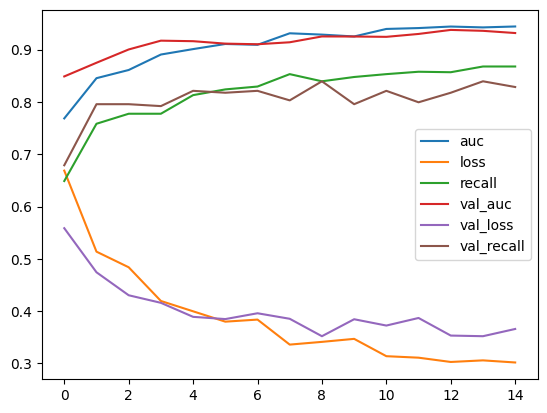

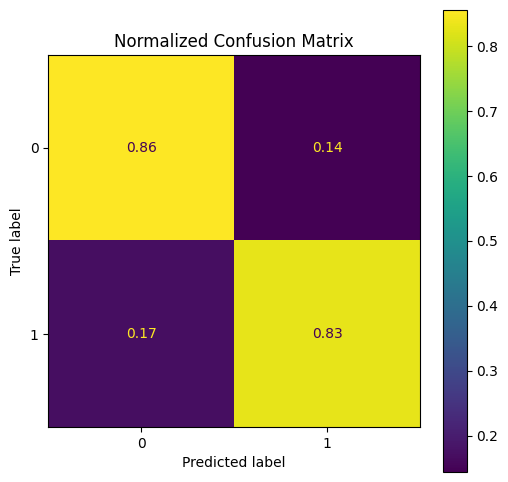

In [97]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(256, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Large_model_cw_v6.keras")

# Original Model without class weight

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_2 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step


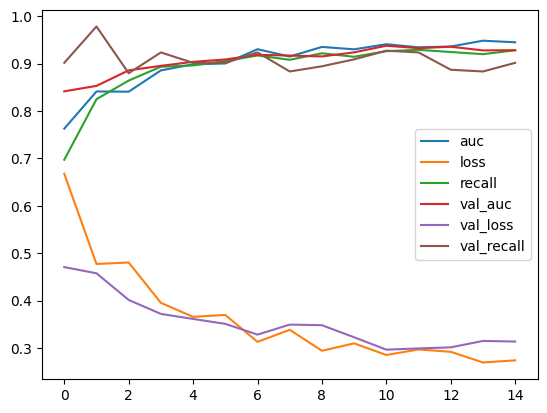

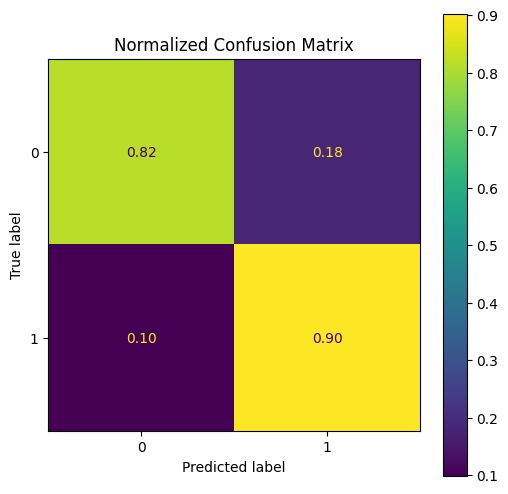

In [98]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
x = layers.Dense(256, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Large_model_v6.keras")

# First refined model with class weights

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_3 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step


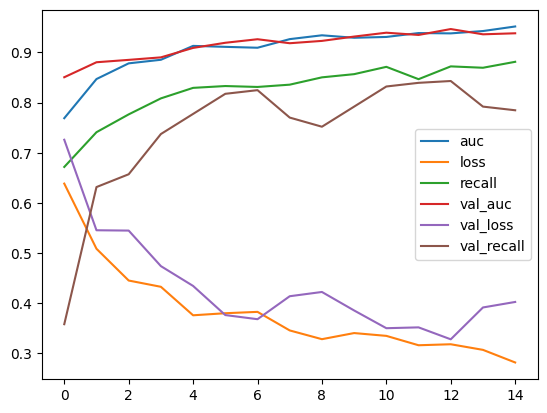

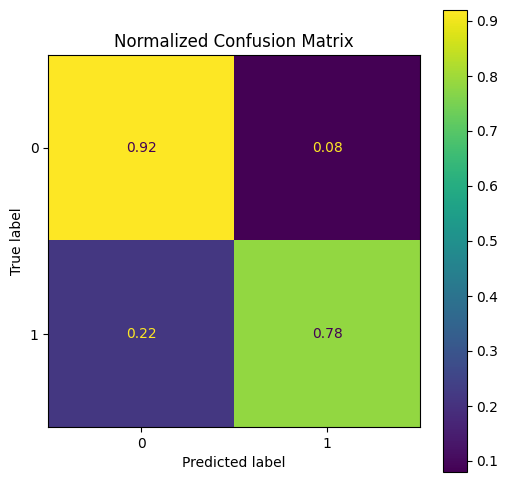

In [99]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_cw_v6.keras")

# First refined model without class weights

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_10 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_5 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_11 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,441 (27.36 MB)

 Trainable params: 133,633 (522.00 KB)

 Non-trainable params: 7,039,808 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step


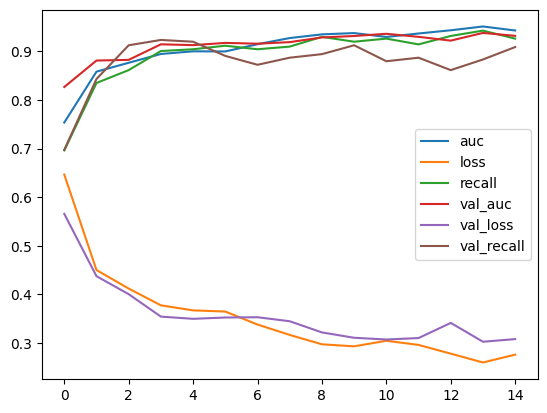

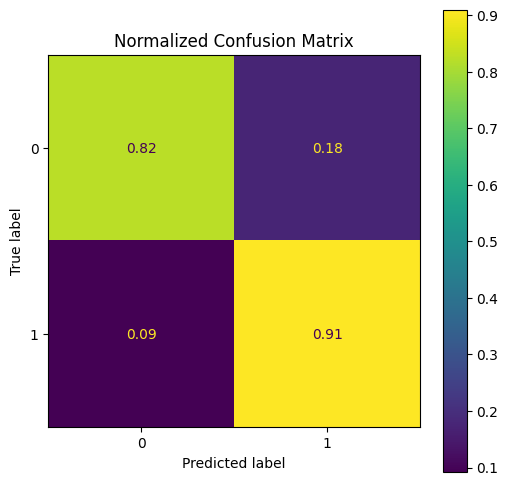

In [101]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_v6.keras")

# Second refined model with class weights

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_12 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_6 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_13 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,107,521 (27.11 MB)

 Trainable params: 67,841 (265.00 KB)

 Non-trainable params: 7,039,680 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step


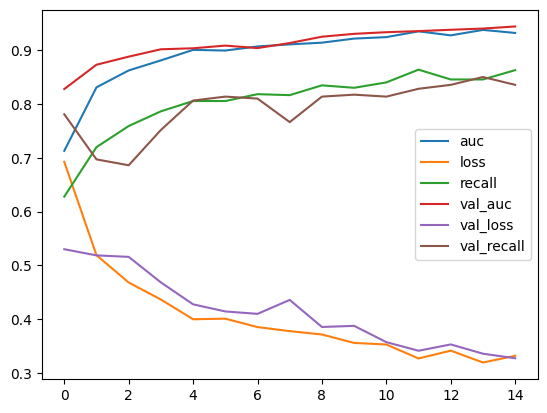

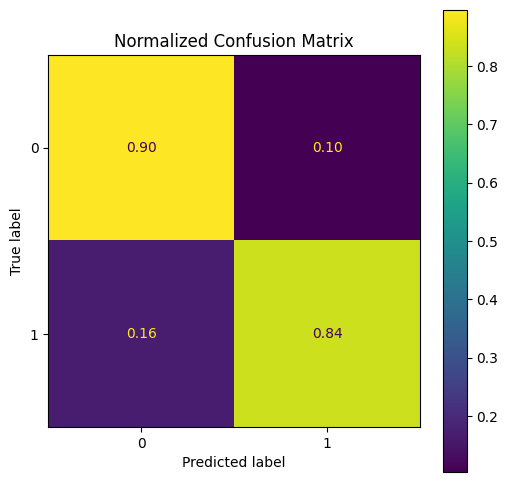

In [102]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_2_cw_v6.keras")

# Second Refinement without class weight

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_14 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_7 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_15 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,107,521 (27.11 MB)

 Trainable params: 67,841 (265.00 KB)

 Non-trainable params: 7,039,680 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step


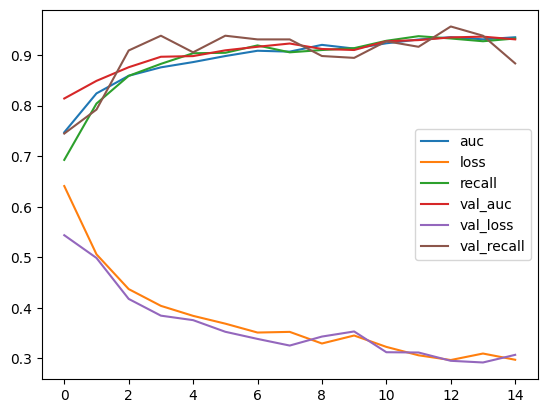

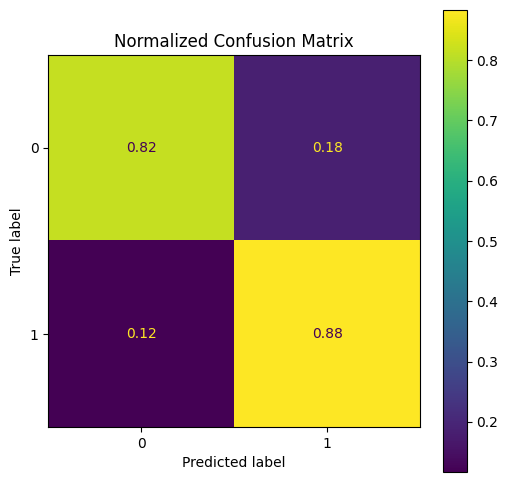

In [103]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
      #  class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_2_v6.keras")

# Third refinement with class weight

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_16 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_8 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_17 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,074,561 (26.99 MB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 7,039,616 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step


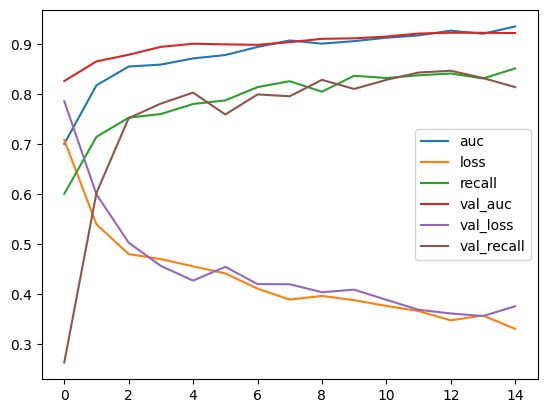

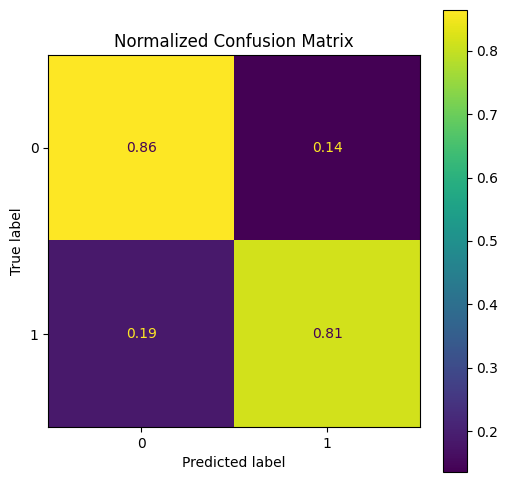

In [104]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_3_cw_v6.keras")

# Third Refinment without class weight

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_18 (TrueDivide)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_9 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_19 (TrueDivide)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,074,561 (26.99 MB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 7,039,616 (26.85 MB)

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step


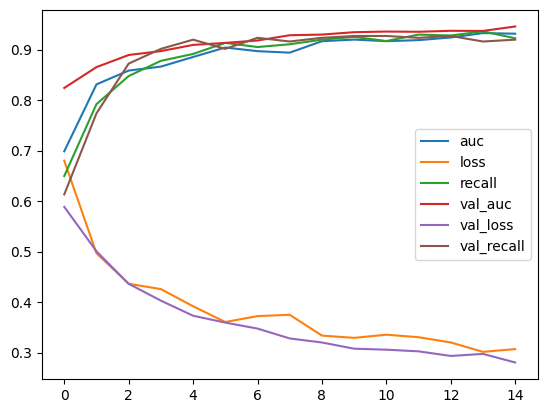

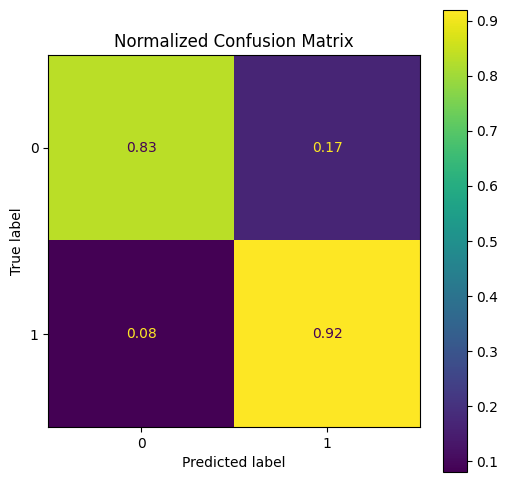

In [105]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
   # layers.RandomZoom(0.10),
   # layers.RandomContrast(0.10),
])

# =========================================================
# PRETRAINED BACKBONE (DenseNet121)
# =========================================================

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze backbone initially
base_model.trainable = False

# =========================================================
# MODEL
# =========================================================

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Augmentation
x = data_augmentation(inputs)

# DenseNet preprocessing
x = tf.keras.applications.densenet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Better than Flatten for histopathology
x = layers.GlobalAveragePooling2D()(x)

# Regularization
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Dense layer for high-level tissue patterns
#x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

x = layers.BatchNormalization()(x)
x = layers.Dropout(0.15)(x)

# Binary classification
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# =========================================================
# COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        #tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        #tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# =========================================================
# INITIAL TRAINING
# =========================================================
n0 = list(y_train).count(0)
n1 = list(y_train).count(1)
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}
history = model.fit(
     X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        #class_weight=class_weight,
        verbose=False
)



pd.DataFrame(history.history).plot()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Probabilities
y_prob = model.predict(X_val).ravel()

# Threshold at 0.5
y_pred = (y_prob >= 0.5).astype(int)

# Normalized confusion matrix
cm = confusion_matrix(
    y_val.astype(int),
    y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot(ax=ax, values_format=".2f")

plt.title("Normalized Confusion Matrix")
plt.show()

model.save("Refined_model_3_v6.keras")